In [4]:
"""
CS216 Project - NYC Congestion Pricing Analysis
Updated to use new MTA dataset (sayj-mze2) with long-format pivoting
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import requests
from io import StringIO

# ── 1. FETCH & RESHAPE DATA ───────────────────────────────────────────────────
print("Fetching MTA Daily Ridership data from NYC Open Data...")

URL = "https://data.ny.gov/resource/sayj-mze2.csv?$limit=50000&$order=date%20ASC"

try:
    response = requests.get(URL, timeout=30)
    response.raise_for_status()
    raw = pd.read_csv(StringIO(response.text))
    print(f"  Loaded {len(raw)} rows, columns: {list(raw.columns)}")

    # Long → wide pivot
    raw["date"] = pd.to_datetime(raw["date"])
    df = raw.pivot_table(index="date", columns="mode", values="count", aggfunc="sum").reset_index()
    df.columns.name = None
    print(f"  Modes available: {[c for c in df.columns if c != 'date']}")

    # Find subway, bus, bridge columns flexibly
    subway_col  = next((c for c in df.columns if "subway" in c.lower()), None)
    bus_col     = next((c for c in df.columns if "bus" in c.lower()), None)
    bridge_col  = next((c for c in df.columns if "bridge" in c.lower() or "tunnel" in c.lower()), None)

except Exception as e:
    print(f"  Could not fetch live data ({e}). Using synthetic fallback.")
    import numpy as np
    np.random.seed(42)
    dates = pd.date_range("2022-01-01", "2026-03-01", freq="D")
    base = 3_200_000
    trend = np.linspace(0, 400_000, len(dates))
    seasonal = 200_000 * np.sin(2 * np.pi * (pd.Series(dates).dt.dayofyear / 365))
    noise = np.random.normal(0, 80_000, len(dates))
    subway = base + trend + seasonal.values + noise
    buses  = 0.28 * subway + np.random.normal(0, 30_000, len(dates))
    bridges = 900_000 + np.random.normal(0, 30_000, len(dates)) - np.linspace(0, 50_000, len(dates))
    df = pd.DataFrame({"date": dates, "Subways": subway, "Buses": buses, "Bridges and Tunnels": bridges})
    subway_col = "Subways"
    bus_col = "Buses"
    bridge_col = "Bridges and Tunnels"


Fetching MTA Daily Ridership data from NYC Open Data...
  Loaded 16619 rows, columns: ['date', 'mode', 'count']
  Modes available: ['AAR', 'BT', 'Bus', 'CBD Entries', 'CRZ Entries', 'LIRR', 'MNR', 'SIR', 'Subway']


In [5]:

# ── 2. CLEAN ──────────────────────────────────────────────────────────────────
df = df[df["date"] >= "2022-01-01"].copy()
df = df.sort_values("date").reset_index(drop=True)

for col in [subway_col, bus_col, bridge_col]:
    if col:
        df[col] = pd.to_numeric(df[col], errors="coerce")

POLICY_DATE = pd.Timestamp("2025-01-05")
df["post_cp"] = df["date"] >= POLICY_DATE

if subway_col:
    df["subway_30d"] = df[subway_col].rolling(30, center=True).mean()
if bus_col:
    df["bus_30d"] = df[bus_col].rolling(30, center=True).mean()
if bridge_col:
    df["bridge_30d"] = df[bridge_col].rolling(30, center=True).mean()

print(f"  Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"  Post-pricing rows: {df['post_cp'].sum()}")


  Date range: 2022-01-01 to 2026-04-19
  Post-pricing rows: 470


In [6]:

# ── 3. SHARED STYLE ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

PRE_COLOR    = "#4C72B0"
POST_COLOR   = "#DD8452"
SMOOTH_COLOR = "#2c2c2c"
LINE_COLOR   = "#C44E52"

def add_policy_line(ax, ypos_frac=0.97):
    ax.axvline(POLICY_DATE, color=LINE_COLOR, linewidth=1.8, linestyle="--", zorder=5)
    ylim = ax.get_ylim()
    ax.text(POLICY_DATE + pd.Timedelta(days=10),
            ylim[0] + (ylim[1] - ylim[0]) * ypos_frac,
            "Congestion Pricing\nImplemented (Jan 5, 2025)",
            fontsize=8, color=LINE_COLOR, va="top")

def format_xaxis(ax):
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)


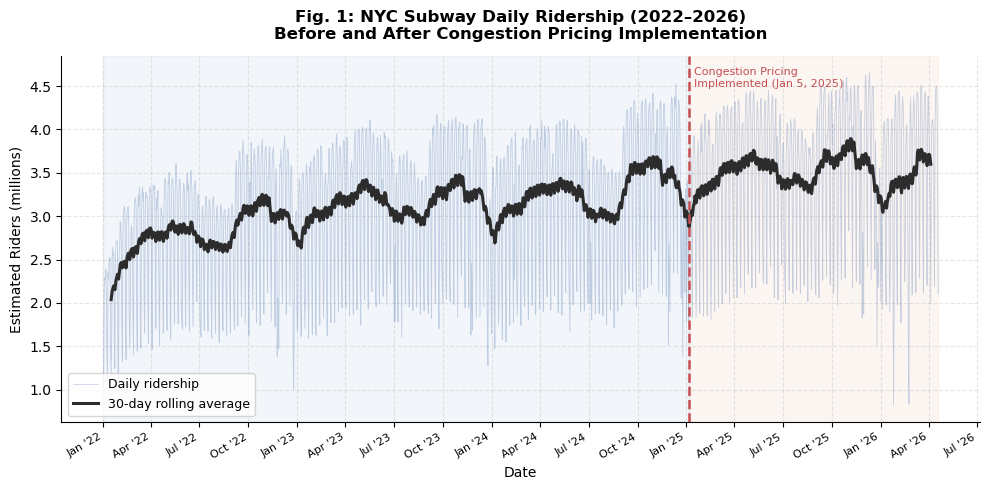

Saved: fig1_subway_ridership.png


In [7]:

# ── FIGURE 1: Subway Ridership ────────────────────────────────────────────────
if subway_col:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.axvspan(df["date"].min(), POLICY_DATE, alpha=0.07, color=PRE_COLOR)
    ax.axvspan(POLICY_DATE, df["date"].max(), alpha=0.07, color=POST_COLOR)
    ax.plot(df["date"], df[subway_col] / 1e6, color=PRE_COLOR, alpha=0.3, linewidth=0.6, label="Daily ridership")
    ax.plot(df["date"], df["subway_30d"] / 1e6, color=SMOOTH_COLOR, linewidth=2.2, label="30-day rolling average")
    add_policy_line(ax)
    format_xaxis(ax)
    ax.set_title("Fig. 1: NYC Subway Daily Ridership (2022–2026)\nBefore and After Congestion Pricing Implementation", fontsize=12, fontweight="bold", pad=12)
    ax.set_ylabel("Estimated Riders (millions)", fontsize=10)
    ax.set_xlabel("Date", fontsize=10)
    ax.legend(fontsize=9, loc="lower left")
    plt.tight_layout()
    plt.savefig("fig1_subway_ridership.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: fig1_subway_ridership.png")


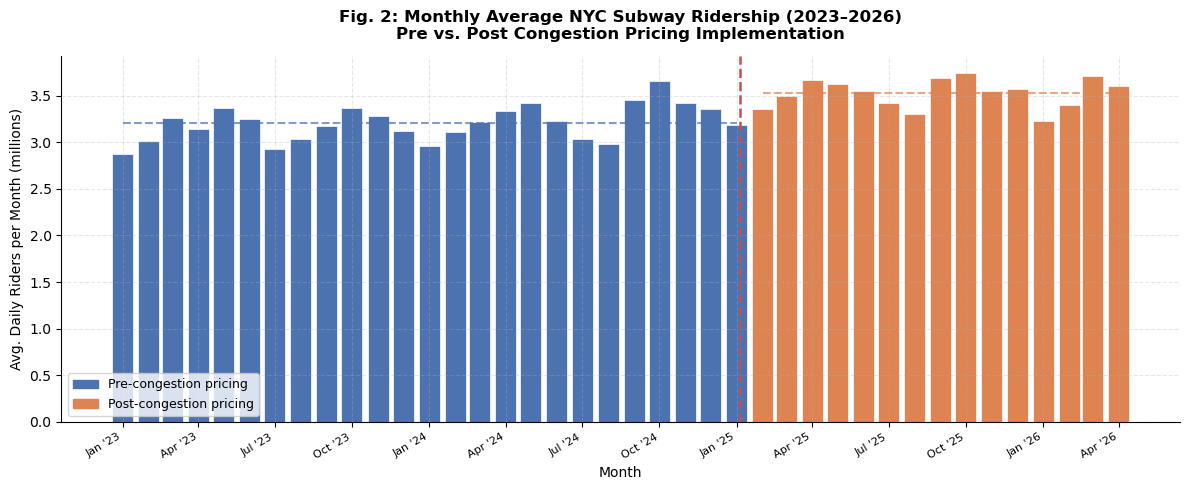

Saved: fig2_monthly_avg_ridership.png


In [8]:

# ── FIGURE 2: Monthly Bar Chart ───────────────────────────────────────────────
if subway_col:
    df["year_month"] = df["date"].dt.to_period("M")
    monthly = df.groupby("year_month")[subway_col].mean().reset_index()
    monthly["date"] = monthly["year_month"].dt.to_timestamp()
    monthly = monthly[monthly["date"] >= "2023-01-01"].copy()
    monthly["post_cp"] = monthly["date"] >= POLICY_DATE

    fig, ax = plt.subplots(figsize=(12, 5))
    colors = [POST_COLOR if p else PRE_COLOR for p in monthly["post_cp"]]
    ax.bar(monthly["date"], monthly[subway_col] / 1e6, color=colors, width=25, edgecolor="white", linewidth=0.5)

    pre_avg  = monthly.loc[~monthly["post_cp"], subway_col].mean() / 1e6
    post_avg = monthly.loc[ monthly["post_cp"], subway_col].mean() / 1e6
    pre_end  = monthly.loc[~monthly["post_cp"], "date"].max()
    post_start = monthly.loc[monthly["post_cp"], "date"].min()
    post_end   = monthly["date"].max()

    ax.hlines(pre_avg,  monthly["date"].min(), pre_end,   colors=PRE_COLOR,  linewidths=1.5, linestyles="--", alpha=0.7, label=f"Pre avg: {pre_avg:.2f}M")
    ax.hlines(post_avg, post_start, post_end, colors=POST_COLOR, linewidths=1.5, linestyles="--", alpha=0.7, label=f"Post avg: {post_avg:.2f}M")
    ax.axvline(POLICY_DATE, color=LINE_COLOR, linewidth=1.8, linestyle="--")

    pre_patch  = mpatches.Patch(color=PRE_COLOR,  label="Pre-congestion pricing")
    post_patch = mpatches.Patch(color=POST_COLOR, label="Post-congestion pricing")
    ax.legend(handles=[pre_patch, post_patch], fontsize=9, loc="lower left")
    format_xaxis(ax)
    ax.set_title("Fig. 2: Monthly Average NYC Subway Ridership (2023–2026)\nPre vs. Post Congestion Pricing Implementation", fontsize=12, fontweight="bold", pad=12)
    ax.set_ylabel("Avg. Daily Riders per Month (millions)", fontsize=10)
    ax.set_xlabel("Month", fontsize=10)
    plt.tight_layout()
    plt.savefig("fig2_monthly_avg_ridership.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: fig2_monthly_avg_ridership.png")


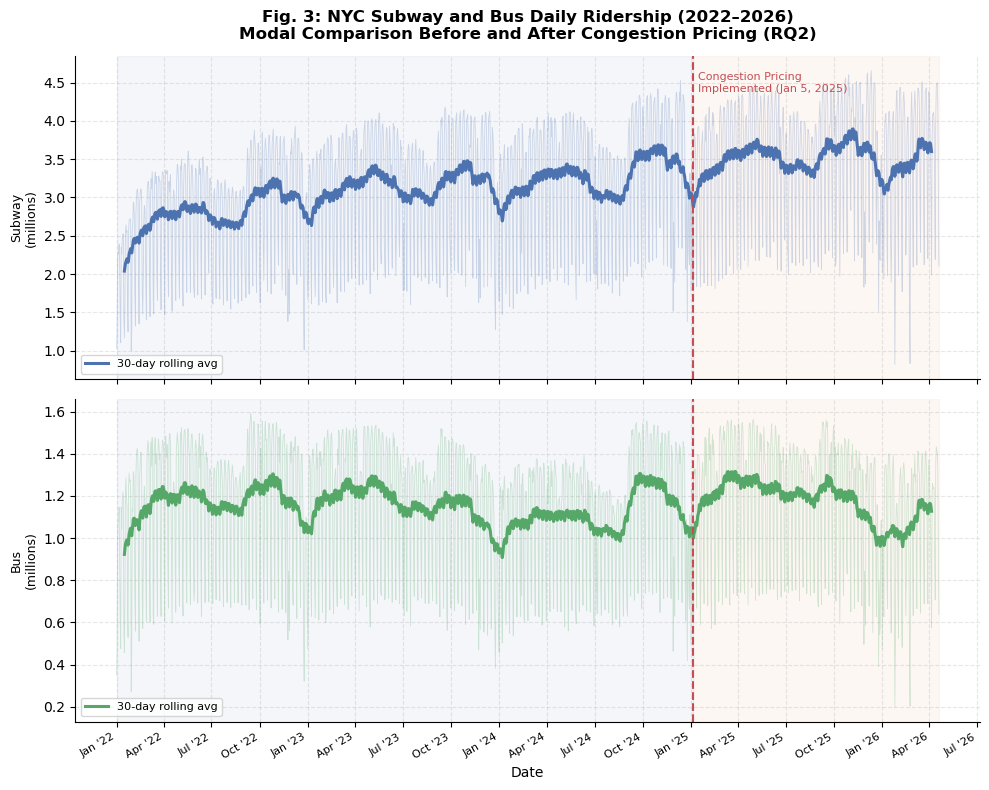

Saved: fig3_modal_comparison.png


In [9]:

# ── FIGURE 3 FIXED: Two-panel subway vs bus only ──────────────────────────────

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for ax, col, smooth_col, label, color in [
    (ax1, "Subway", "subway_30d",  "Subway", "#4C72B0"),
    (ax2, "Bus",    "bus_30d",     "Bus",    "#55A868"),
]:
    ax.axvspan(df["date"].min(), POLICY_DATE, alpha=0.06, color=PRE_COLOR)
    ax.axvspan(POLICY_DATE, df["date"].max(), alpha=0.06, color=POST_COLOR)
    ax.plot(df["date"], df[col] / 1e6, color=color, alpha=0.25, linewidth=0.6)
    ax.plot(df["date"], df[smooth_col] / 1e6, color=color, linewidth=2.2, label="30-day rolling avg")
    ax.axvline(POLICY_DATE, color=LINE_COLOR, linewidth=1.5, linestyle="--")
    ax.set_ylabel(f"{label}\n(millions)", fontsize=9)
    ax.legend(fontsize=8, loc="lower left")

ylim1 = ax1.get_ylim()
ax1.text(POLICY_DATE + pd.Timedelta(days=10),
         ylim1[0] + (ylim1[1] - ylim1[0]) * 0.95,
         "Congestion Pricing\nImplemented (Jan 5, 2025)",
         fontsize=8, color=LINE_COLOR, va="top")

ax1.set_title("Fig. 3: NYC Subway and Bus Daily Ridership (2022–2026)\nModal Comparison Before and After Congestion Pricing (RQ2)",
              fontsize=12, fontweight="bold", pad=12)
ax2.set_xlabel("Date", fontsize=10)
format_xaxis(ax2)
plt.tight_layout()
plt.savefig("fig3_modal_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig3_modal_comparison.png")

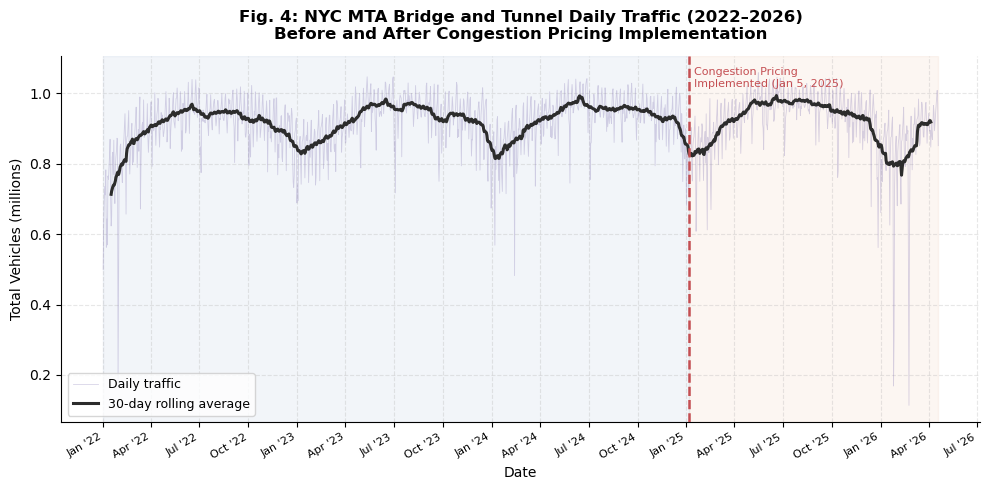

Saved: fig4_bridge_tunnel_traffic.png

All figures saved! Download from Files panel on the left.


In [10]:

# ── FIGURE 4: Bridge & Tunnel Traffic (FIXED for new dataset) ─────────────────

bridge_col_fixed = "BT"  # mode name in new dataset

if bridge_col_fixed in df.columns:
    df["bridge_30d_fixed"] = df[bridge_col_fixed].rolling(30, center=True).mean()

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.axvspan(df["date"].min(), POLICY_DATE, alpha=0.07, color=PRE_COLOR)
    ax.axvspan(POLICY_DATE, df["date"].max(), alpha=0.07, color=POST_COLOR)

    ax.plot(df["date"], df[bridge_col_fixed] / 1e6,
            color="#8172B2", alpha=0.3, linewidth=0.6, label="Daily traffic")
    ax.plot(df["date"], df["bridge_30d_fixed"] / 1e6,
            color="#2c2c2c", linewidth=2.2, label="30-day rolling average")

    add_policy_line(ax)
    format_xaxis(ax)

    ax.set_title("Fig. 4: NYC MTA Bridge and Tunnel Daily Traffic (2022–2026)\nBefore and After Congestion Pricing Implementation",
                 fontsize=12, fontweight="bold", pad=12)
    ax.set_ylabel("Total Vehicles (millions)", fontsize=10)
    ax.set_xlabel("Date", fontsize=10)
    ax.legend(fontsize=9, loc="lower left")

    plt.tight_layout()
    plt.savefig("fig4_bridge_tunnel_traffic.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: fig4_bridge_tunnel_traffic.png")
else:
    print(f"BT column not found. Available columns: {list(df.columns)}")

print("\nAll figures saved! Download from Files panel on the left.")